In [1]:
library(dplyr)

Warning message:
“package ‘dplyr’ was built under R version 4.3.2”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [ ]:
CA1_path <- "./03_Histone/Paired-Tag_DMR/output/03_H3K4me1_Allsubclass/CA1/"
CA1_files <- list.files(path = CA1_path, pattern = "\\.tmp$", full.names = TRUE)
CA1_files

[1] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/03_H3K4me1_Allsubclass/CA1//Paired-Tag_H3K4me1_FC_CT.mm10.tmp"     
 [2] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/03_H3K4me1_Allsubclass/CA1//Paired-Tag_H3K4me1_FC_L2_3.mm10.tmp"   
 [3] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/03_H3K4me1_Allsubclass/CA1//Paired-Tag_H3K4me1_FC_L4_Rorb.mm10.tmp"
 [4] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/03_H3K4me1_Allsubclass/CA1//Paired-Tag_H3K4me1_FC_L5.mm10.tmp"     
 [5] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/03_H3K4me1_Allsubclass/CA1//Paired-Tag_H3K4me1_FC_L6.mm10.tmp"     
 [6] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/03_H3K4me1_Allsubclass/CA1//Paired-Tag_H3K4me1_FC_NP.mm10.tmp"     
 [7] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/03_H3K4me1_Allsubclass/CA1//Paired-Tag_H3K4me1_HC_CA1.mm10.tmp"    
 [8] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/03_H3K4me1_Allsubclass/CA1//Paired-Tag_H3K4me1_HC_CA23.mm10.tmp"   
 [9] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/03_H3K4me1_Allsubclass/CA1//Paired-Tag_H3K4me1_HC_DG.mm10.tmp"     
[10] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/03_H3K4me1_Allsubclass/CA1//Paired-Tag_H3K4me1_In_CGE.mm10.tmp"    
[11] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/03_H3K4me1_Allsubclass/CA1//Paired-Tag_H3K4me1_In_Pvalb.mm10.tmp"  
[12] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/03_H3K4me1_Allsubclass/CA1//Paired-Tag_H3K4me1_In_Sst.mm10.tmp"

In [3]:
merged_CA1 <- NULL

In [4]:
gsub(".*(_FC_|_HC_|_In_)(.*?)\\.mm10\\.tmp$","\\2","Paired-Tag_H3K4me1_FC_CT.mm10.tmp")

[1] "CT"

In [5]:
gsub(".*(_FC_|_HC_|_In_)(.*?)\\.mm10\\.tmp$","\\2","Paired-Tag_H3K4me1_FC_L2_3.mm10.tmp")

[1] "L2_3"

In [6]:
gsub(".*(_FC_|_HC_|_In_)(.*?)\\.mm10\\.tmp$","\\2","Paired-Tag_H3K4me1_HC_DG.mm10.tmp")
gsub(".*(_FC_|_HC_|_In_)(.*?)\\.mm10\\.tmp$","\\2","Paired-Tag_H3K4me1_In_Pvalb.mm10.tmp")

[1] "DG"

[1] "Pvalb"

In [7]:
for (file in CA1_files) {

  base_name <- gsub(".*(_FC_|_HC_|_In_)(.*?)\\.mm10\\.tmp$", "\\2", basename(file))
  print(base_name)

  tmp_data <- read.table(file, header = TRUE, sep = "\t", stringsAsFactors = FALSE)

  if (!is.null(merged_CA1)) {
    if (!identical(merged_CA1[, 1], tmp_data[, 1])) {
      stop(paste("The first column in file", file, "is not identical to the previous files!"))
    }
  }

  colnames(tmp_data)[2:3] <- paste(base_name, colnames(tmp_data)[2:3], sep = "_")

  if (is.null(merged_CA1)) {
    merged_CA1 <- tmp_data
  } else {
    merged_CA1 <- cbind(merged_CA1, tmp_data[, -1])
  }
}

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


In [8]:
merged_CA1

hyperDHMR,CT_signal_sum,CT_signal_sum_log10,L2_3_signal_sum,L2_3_signal_sum_log10,L4_Rorb_signal_sum,L4_Rorb_signal_sum_log10,L5_signal_sum,L5_signal_sum_log10,L6_signal_sum,⋯,CA23_signal_sum,CA23_signal_sum_log10,DG_signal_sum,DG_signal_sum_log10,CGE_signal_sum,CGE_signal_sum_log10,Pvalb_signal_sum,Pvalb_signal_sum_log10,Sst_signal_sum,Sst_signal_sum_log10
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:4000851-4001851,0.000000,0.0000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.0000,⋯,0.00000,0.000000,0.000000,0.0000000,0.0000,0.0000000,0.0000,0.000000,0.00000,0.000000
chr1:4794017-4795017,0.000000,0.0000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.0000,⋯,0.00000,0.000000,0.000000,0.0000000,0.0000,0.0000000,0.0000,0.000000,0.00000,0.000000
chr1:4947085-4948085,210.956860,2.3262475,286.797080,2.459086,0.00000,0.000000,0.00000,0.000000,0.0000,⋯,0.00000,0.000000,31.360431,1.5100143,0.0000,0.0000000,0.0000,0.000000,0.00000,0.000000
chr1:5336791-5337791,17.049958,1.2564762,118.426186,2.077100,282.92838,2.453209,282.99586,2.453312,887.7704,⋯,0.00000,0.000000,0.000000,0.0000000,0.0000,0.0000000,0.0000,0.000000,0.00000,0.000000
chr1:5745992-5746992,0.000000,0.0000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.0000,⋯,0.00000,0.000000,0.000000,0.0000000,0.0000,0.0000000,0.0000,0.000000,0.00000,0.000000
chr1:5825616-5826616,0.000000,0.0000000,29.006831,1.477220,0.00000,0.000000,0.00000,0.000000,0.0000,⋯,0.00000,0.000000,0.000000,0.0000000,0.0000,0.0000000,0.0000,0.000000,0.00000,0.000000
chr1:6177024-6178024,0.000000,0.0000000,72.189836,1.864451,312.97376,2.496893,91.31860,1.965289,166.0133,⋯,0.00000,0.000000,0.000000,0.0000000,0.0000,0.0000000,0.0000,0.000000,106.66331,2.032068
chr1:7060591-7061591,144.491040,2.1628362,215.588434,2.335635,156.48696,2.197245,83.00861,1.924324,264.3339,⋯,209.05287,2.322329,121.305097,2.0874446,359.1310,2.5564605,124.9919,2.100343,450.48722,2.654645
chr1:8211551-8212551,115.881802,2.0677469,0.000000,0.000000,0.00000,0.000000,73.23752,1.870623,0.0000,⋯,110.44821,2.047073,0.000000,0.0000000,128.8116,2.1133137,0.0000,0.000000,0.00000,0.000000


In [9]:
merged_CA1 <- merged_CA1[, c(1, grep("signal_sum_log10", colnames(merged_CA1)))]

merged_CA1

hyperDHMR,CT_signal_sum_log10,L2_3_signal_sum_log10,L4_Rorb_signal_sum_log10,L5_signal_sum_log10,L6_signal_sum_log10,NP_signal_sum_log10,CA1_signal_sum_log10,CA23_signal_sum_log10,DG_signal_sum_log10,CGE_signal_sum_log10,Pvalb_signal_sum_log10,Sst_signal_sum_log10
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:4000851-4001851,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000000,0.0000000,0.000000,0.000000
chr1:4794017-4795017,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.458409,0.000000,0.0000000,0.0000000,0.000000,0.000000
chr1:4947085-4948085,2.3262475,2.459086,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.5100143,0.0000000,0.000000,0.000000
chr1:5336791-5337791,1.2564762,2.077100,2.453209,2.453312,2.948790,0.000000,2.737559,0.000000,0.0000000,0.0000000,0.000000,0.000000
chr1:5745992-5746992,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000000,0.0000000,0.000000,0.000000
chr1:5825616-5826616,0.0000000,1.477220,0.000000,0.000000,0.000000,0.000000,1.894791,0.000000,0.0000000,0.0000000,0.000000,0.000000
chr1:6177024-6178024,0.0000000,1.864451,2.496893,1.965289,2.222751,0.000000,2.054775,0.000000,0.0000000,0.0000000,0.000000,2.032068
chr1:7060591-7061591,2.1628362,2.335635,2.197245,1.924324,2.423793,2.895325,2.359450,2.322329,2.0874446,2.5564605,2.100343,2.654645
chr1:8211551-8212551,2.0677469,0.000000,0.000000,1.870623,0.000000,0.000000,0.000000,2.047073,0.0000000,2.1133137,0.000000,0.000000


In [10]:
library(tidyverse)

Warning message:
“package ‘tidyverse’ was built under R version 4.3.3”
Warning message:
“package ‘ggplot2’ was built under R version 4.3.3”
Warning message:
“package ‘readr’ was built under R version 4.3.3”
Warning message:
“package ‘stringr’ was built under R version 4.3.2”
Warning message:
“package ‘forcats’ was built under R version 4.3.3”
── Attaching core tidyverse packages ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ readr     2.1.5
✔ ggplot2   3.5.2     ✔ stringr   1.5.1
✔ lubridate 1.9.3     ✔ tibble    3.2.1
✔ purrr     1.0.2     ✔ tidyr     1.3.0
── Conflicts ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all

In [11]:
merged_CA1 <- merged_CA1 %>% column_to_rownames("hyperDHMR")
merged_CA1

,CT_signal_sum_log10,L2_3_signal_sum_log10,L4_Rorb_signal_sum_log10,L5_signal_sum_log10,L6_signal_sum_log10,NP_signal_sum_log10,CA1_signal_sum_log10,CA23_signal_sum_log10,DG_signal_sum_log10,CGE_signal_sum_log10,Pvalb_signal_sum_log10,Sst_signal_sum_log10
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:4000851-4001851,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000000,0.0000000,0.000000,0.000000
chr1:4794017-4795017,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.458409,0.000000,0.0000000,0.0000000,0.000000,0.000000
chr1:4947085-4948085,2.3262475,2.459086,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.5100143,0.0000000,0.000000,0.000000
chr1:5336791-5337791,1.2564762,2.077100,2.453209,2.453312,2.948790,0.000000,2.737559,0.000000,0.0000000,0.0000000,0.000000,0.000000
chr1:5745992-5746992,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000000,0.0000000,0.000000,0.000000
chr1:5825616-5826616,0.0000000,1.477220,0.000000,0.000000,0.000000,0.000000,1.894791,0.000000,0.0000000,0.0000000,0.000000,0.000000
chr1:6177024-6178024,0.0000000,1.864451,2.496893,1.965289,2.222751,0.000000,2.054775,0.000000,0.0000000,0.0000000,0.000000,2.032068
chr1:7060591-7061591,2.1628362,2.335635,2.197245,1.924324,2.423793,2.895325,2.359450,2.322329,2.0874446,2.5564605,2.100343,2.654645
chr1:8211551-8212551,2.0677469,0.000000,0.000000,1.870623,0.000000,0.000000,0.000000,2.047073,0.0000000,2.1133137,0.000000,0.000000


In [12]:
colnames(merged_CA1) <- gsub("_signal_sum_log10$","",colnames(merged_CA1))
merged_CA1

,CT,L2_3,L4_Rorb,L5,L6,NP,CA1,CA23,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:4000851-4001851,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000000,0.0000000,0.000000,0.000000
chr1:4794017-4795017,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.458409,0.000000,0.0000000,0.0000000,0.000000,0.000000
chr1:4947085-4948085,2.3262475,2.459086,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.5100143,0.0000000,0.000000,0.000000
chr1:5336791-5337791,1.2564762,2.077100,2.453209,2.453312,2.948790,0.000000,2.737559,0.000000,0.0000000,0.0000000,0.000000,0.000000
chr1:5745992-5746992,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000000,0.0000000,0.000000,0.000000
chr1:5825616-5826616,0.0000000,1.477220,0.000000,0.000000,0.000000,0.000000,1.894791,0.000000,0.0000000,0.0000000,0.000000,0.000000
chr1:6177024-6178024,0.0000000,1.864451,2.496893,1.965289,2.222751,0.000000,2.054775,0.000000,0.0000000,0.0000000,0.000000,2.032068
chr1:7060591-7061591,2.1628362,2.335635,2.197245,1.924324,2.423793,2.895325,2.359450,2.322329,2.0874446,2.5564605,2.100343,2.654645
chr1:8211551-8212551,2.0677469,0.000000,0.000000,1.870623,0.000000,0.000000,0.000000,2.047073,0.0000000,2.1133137,0.000000,0.000000


In [13]:
colnames(merged_CA1)[which(colnames(merged_CA1) %in% "L4_Rorb")] <- "L4"

In [14]:
merged_CA1

,CT,L2_3,L4,L5,L6,NP,CA1,CA23,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:4000851-4001851,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000000,0.0000000,0.000000,0.000000
chr1:4794017-4795017,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.458409,0.000000,0.0000000,0.0000000,0.000000,0.000000
chr1:4947085-4948085,2.3262475,2.459086,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.5100143,0.0000000,0.000000,0.000000
chr1:5336791-5337791,1.2564762,2.077100,2.453209,2.453312,2.948790,0.000000,2.737559,0.000000,0.0000000,0.0000000,0.000000,0.000000
chr1:5745992-5746992,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000000,0.0000000,0.000000,0.000000
chr1:5825616-5826616,0.0000000,1.477220,0.000000,0.000000,0.000000,0.000000,1.894791,0.000000,0.0000000,0.0000000,0.000000,0.000000
chr1:6177024-6178024,0.0000000,1.864451,2.496893,1.965289,2.222751,0.000000,2.054775,0.000000,0.0000000,0.0000000,0.000000,2.032068
chr1:7060591-7061591,2.1628362,2.335635,2.197245,1.924324,2.423793,2.895325,2.359450,2.322329,2.0874446,2.5564605,2.100343,2.654645
chr1:8211551-8212551,2.0677469,0.000000,0.000000,1.870623,0.000000,0.000000,0.000000,2.047073,0.0000000,2.1133137,0.000000,0.000000


In [15]:
merged_CA1$merge_L5 <- (merged_CA1$L5+merged_CA1$L6)/2
merged_CA1 <- merged_CA1 %>% dplyr::select(-c(L5,L6))
colnames(merged_CA1)[which(colnames(merged_CA1) == "merge_L5")] <- "L5"
merged_CA1

,CT,L2_3,L4,NP,CA1,CA23,DG,CGE,Pvalb,Sst,L5
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:4000851-4001851,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000000,0.0000000,0.000000,0.000000,0.0000000
chr1:4794017-4795017,0.0000000,0.000000,0.000000,0.000000,2.458409,0.000000,0.0000000,0.0000000,0.000000,0.000000,0.0000000
chr1:4947085-4948085,2.3262475,2.459086,0.000000,0.000000,0.000000,0.000000,1.5100143,0.0000000,0.000000,0.000000,0.0000000
chr1:5336791-5337791,1.2564762,2.077100,2.453209,0.000000,2.737559,0.000000,0.0000000,0.0000000,0.000000,0.000000,2.7010508
chr1:5745992-5746992,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000000,0.0000000,0.000000,0.000000,0.0000000
chr1:5825616-5826616,0.0000000,1.477220,0.000000,0.000000,1.894791,0.000000,0.0000000,0.0000000,0.000000,0.000000,0.0000000
chr1:6177024-6178024,0.0000000,1.864451,2.496893,0.000000,2.054775,0.000000,0.0000000,0.0000000,0.000000,2.032068,2.0940201
chr1:7060591-7061591,2.1628362,2.335635,2.197245,2.895325,2.359450,2.322329,2.0874446,2.5564605,2.100343,2.654645,2.1740583
chr1:8211551-8212551,2.0677469,0.000000,0.000000,0.000000,0.000000,2.047073,0.0000000,2.1133137,0.000000,0.000000,0.9353117


In [16]:
# celltype_order <- c("L2_3","L4","L5","L6","CA1","CA23","NP","CT","DG","CGE","Pvalb","Sst")
celltype_order <- c("L2_3","L4","L5","CA1","CA23","NP","CT","DG","CGE","Pvalb","Sst")
celltype_order

[1] "L2_3"  "L4"    "L5"    "CA1"   "CA23"  "NP"    "CT"    "DG"    "CGE"  
[10] "Pvalb" "Sst"

In [17]:
merged_CA1 <- merged_CA1[,celltype_order]
merged_CA1

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:4000851-4001851,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.0000000,0.0000000,0.0000000,0.000000,0.000000
chr1:4794017-4795017,0.000000,0.000000,0.0000000,2.458409,0.000000,0.000000,0.0000000,0.0000000,0.0000000,0.000000,0.000000
chr1:4947085-4948085,2.459086,0.000000,0.0000000,0.000000,0.000000,0.000000,2.3262475,1.5100143,0.0000000,0.000000,0.000000
chr1:5336791-5337791,2.077100,2.453209,2.7010508,2.737559,0.000000,0.000000,1.2564762,0.0000000,0.0000000,0.000000,0.000000
chr1:5745992-5746992,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.0000000,0.0000000,0.0000000,0.000000,0.000000
chr1:5825616-5826616,1.477220,0.000000,0.0000000,1.894791,0.000000,0.000000,0.0000000,0.0000000,0.0000000,0.000000,0.000000
chr1:6177024-6178024,1.864451,2.496893,2.0940201,2.054775,0.000000,0.000000,0.0000000,0.0000000,0.0000000,0.000000,2.032068
chr1:7060591-7061591,2.335635,2.197245,2.1740583,2.359450,2.322329,2.895325,2.1628362,2.0874446,2.5564605,2.100343,2.654645
chr1:8211551-8212551,0.000000,0.000000,0.9353117,0.000000,2.047073,0.000000,2.0677469,0.0000000,2.1133137,0.000000,0.000000


In [18]:
colMeans(merged_CA1) %>% data.frame() %>% t()

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
.,1.123019,0.724425,0.7475068,1.343832,1.019152,0.2986887,0.7283737,1.112347,0.67638,0.5056716,0.5310719


In [19]:
library(pheatmap)

Warning message:
“package ‘pheatmap’ was built under R version 4.3.3”


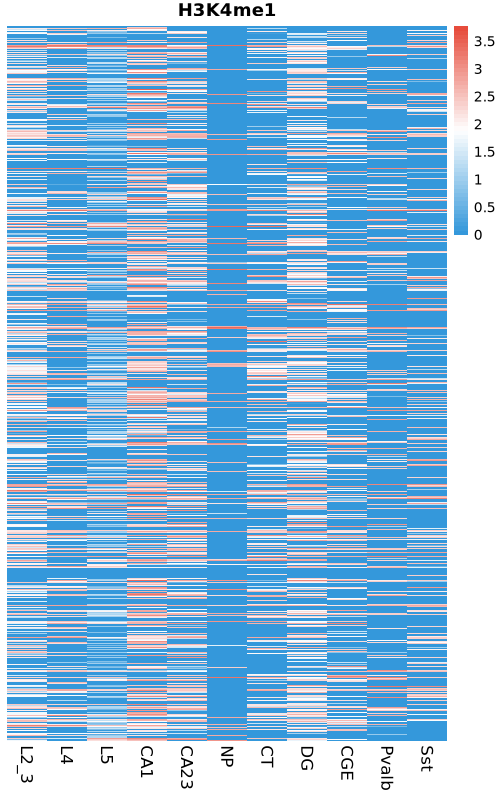

In [20]:
options(repr.plot.width = 5, repr.plot.height = 8, repr.plot.res = 100)
pheatmap(
  merged_CA1,
  cluster_rows = FALSE,
  cluster_cols = FALSE,
  show_rownames = FALSE,
  color = colorRampPalette(c("#3498db", "white", "#e74c3c"))(50),
  main = "H3K4me1",
  fontsize_row = 12,
  fontsize_col = 12 
)

In [21]:
process_files <- function(input_path, pattern = "\\.tmp$", celltype_order) {
  files <- list.files(path = input_path, pattern = pattern, full.names = TRUE)
  merged_data <- NULL

  for (file in files) {
    base_name <- gsub(".*(_FC_|_HC_|_In_)(.*?)\\.mm10\\.tmp$", "\\2", basename(file))
    print(base_name)

    tmp_data <- read.table(file, header = TRUE, sep = "\t", stringsAsFactors = FALSE)

    if (!is.null(merged_data)) {
      if (!identical(merged_data[, 1], tmp_data[, 1])) {
        stop(paste("The first column in file", file, "is not identical to the previous files!"))
      }
    }

    colnames(tmp_data)[2:3] <- paste(base_name, colnames(tmp_data)[2:3], sep = "_")

    if (is.null(merged_data)) {
      merged_data <- tmp_data
    } else {
      merged_data <- cbind(merged_data, tmp_data[, -1])
    }
  }

  merged_data <- merged_data[, c(1, grep("signal_sum_log10", colnames(merged_data)))]
  merged_data <- merged_data %>% column_to_rownames("hyperDHMR")
  colnames(merged_data) <- gsub("_signal_sum_log10$", "", colnames(merged_data))

  colnames(merged_data)[which(colnames(merged_data) %in% "L4_Rorb")] <- "L4"

  merged_data$merge_L5 <- (merged_data$L5+merged_data$L6)/2
  merged_data <- merged_data %>% dplyr::select(-c(L5,L6))
  colnames(merged_data)[which(colnames(merged_data) == "merge_L5")] <- "L5"

  celltype_order <- c("L2_3", "L4", "L5", "CA1", "CA23", "NP", "CT", "DG", "CGE", "Pvalb", "Sst")

  merged_data <- merged_data[, celltype_order]
  
  return(merged_data)
}

In [ ]:
H3K4me1_path <- "./03_Histone/Paired-Tag_DMR/output/03_H3K4me1_Allsubclass/"

In [23]:
subdirs <- list.dirs(path = H3K4me1_path, full.names = TRUE, recursive = FALSE)
subdirs

[1] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/03_H3K4me1_Allsubclass//CA1"  
 [2] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/03_H3K4me1_Allsubclass//CA23" 
 [3] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/03_H3K4me1_Allsubclass//CT"   
 [4] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/03_H3K4me1_Allsubclass//DG"   
 [5] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/03_H3K4me1_Allsubclass//L2_3" 
 [6] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/03_H3K4me1_Allsubclass//L4_5" 
 [7] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/03_H3K4me1_Allsubclass//L5"   
 [8] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/03_H3K4me1_Allsubclass//Lamp5"
 [9] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/03_H3K4me1_Allsubclass//NP"   
[10] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/03_H3K4me1_Allsubclass//Pvalb"
[11] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/03_H3K4me1_Allsubclass//Sncg" 
[12] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/03_H3K4me1_Allsubclass//Sst"

In [24]:
basename(subdirs)

[1] "CA1"   "CA23"  "CT"    "DG"    "L2_3"  "L4_5"  "L5"    "Lamp5" "NP"   
[10] "Pvalb" "Sncg"  "Sst"

In [ ]:
L2_3 <- process_files('./03_Histone/Paired-Tag_DMR/output/03_H3K4me1_Allsubclass/L2_3', 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

L2_3

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:6943646-6944646,1.522161,0.0000000,0.0000000,0.0000000,0.8653958,0.000000,0.000000,1.6444771,0.0000000,2.1579036,0.000000
chr1:9780815-9781815,2.478397,0.5246949,2.7405086,0.0000000,2.1421264,0.000000,2.329198,1.8307447,0.0000000,0.0000000,0.000000
chr1:20575278-20576278,0.000000,0.0000000,0.0000000,0.0000000,0.0000000,0.000000,0.000000,0.0000000,0.0000000,0.0000000,0.000000
chr1:31350491-31351491,2.220224,2.1972446,0.9826446,0.0000000,0.0000000,0.000000,0.000000,0.0000000,0.0000000,0.0000000,0.000000
chr1:31956491-31957491,0.000000,0.0000000,0.0000000,0.0000000,0.0000000,0.000000,0.000000,0.0000000,0.0000000,0.0000000,0.000000
chr1:35665086-35666086,2.348136,2.4968937,1.0678835,0.0000000,0.0000000,0.000000,0.000000,1.8307445,2.5999222,0.0000000,0.000000
chr1:40205252-40206252,1.825199,0.0000000,0.0000000,0.0000000,0.0000000,0.000000,0.000000,1.4381123,0.0000000,0.0000000,0.000000
chr1:41656765-41657765,0.000000,0.0000000,0.0000000,0.7851706,0.0000000,0.000000,0.000000,2.1041759,0.0000000,0.0000000,0.000000
chr1:41760547-41761547,2.214626,2.7972310,0.8933011,2.1427979,0.9190225,0.000000,0.000000,1.2523984,0.0000000,2.3607986,2.351166


In [26]:
L2_3_mean <- colMeans(L2_3) %>% data.frame() %>% t()
rownames(L2_3_mean) <- "L2_3"
L2_3_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
L2_3,1.750771,1.204635,1.100281,0.7990348,0.7674176,0.2918486,0.7737202,1.015986,0.7139991,0.4884949,0.5533003


In [ ]:
L4_5 <- process_files('./03_Histone/Paired-Tag_DMR/output/03_H3K4me1_Allsubclass/L4_5', 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

L4_5

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3931138-3932138,0.000000,2.849269,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:7536517-7537517,0.000000,2.489471,1.1879151,0.000000,1.575562,0.000000,0.000000,0.000000,1.737549,0.000000,0.000000
chr1:9794519-9795519,1.941885,3.140457,2.4570394,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:14839073-14840073,1.036185,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:14914779-14915779,0.000000,2.367778,1.4989292,0.000000,0.000000,2.731937,0.000000,2.427968,2.208476,0.000000,0.000000
chr1:18962969-18963969,2.470455,2.646324,2.5179414,2.641426,0.000000,0.000000,1.954970,2.181644,1.431675,1.603038,2.211875
chr1:22023298-22024298,2.001959,0.000000,0.0000000,0.000000,1.185328,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:24906164-24907164,2.049260,2.181425,1.2068584,0.000000,1.717923,0.000000,1.057033,1.322577,1.052280,0.000000,0.000000
chr1:27500435-27501435,2.373913,2.116887,0.9971826,2.166282,2.441588,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [28]:
L4_5_mean <- colMeans(L4_5) %>% data.frame() %>% t()
rownames(L4_5_mean) <- "L4_5"
L4_5_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
L4_5,1.513403,1.417371,1.139661,0.8213778,0.7551639,0.36335,0.7817638,0.9744871,0.6897241,0.5923153,0.6298032


In [ ]:
L5 <- process_files('./03_Histone/Paired-Tag_DMR/output/03_H3K4me1_Allsubclass/L5', 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

L5

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:9892852-9893852,2.338469,1.855713,0.0000000,2.6874305,2.0481451,0.000000,0.000000,1.4972925,0.0000000,0.0000000,2.353443
chr1:11320903-11321903,1.976223,2.671221,1.4599898,0.0000000,0.0000000,0.000000,1.212615,0.0000000,0.0000000,1.4245155,0.000000
chr1:15848796-15849796,2.703122,2.803260,2.8627760,2.1662823,1.8373122,2.741137,3.358909,2.3064414,0.0000000,0.0000000,1.844517
chr1:20499848-20500848,1.362251,1.517504,2.1676516,2.5300831,1.8048103,0.000000,0.000000,1.8307447,0.0000000,2.7273657,0.000000
chr1:22220457-22221457,0.000000,0.000000,1.2196316,0.0000000,0.0000000,0.000000,0.000000,0.0000000,0.0000000,0.0000000,0.000000
chr1:22315425-22316425,2.454121,0.000000,1.1399315,1.6133540,0.0000000,3.125386,2.162836,2.0118012,2.0390727,2.5945125,1.733162
chr1:26778141-26779141,1.744482,0.000000,0.0000000,0.0000000,0.0000000,0.000000,0.000000,0.0000000,0.0000000,0.0000000,0.000000
chr1:27662663-27663663,0.000000,0.000000,0.9955879,1.0075760,0.0000000,0.000000,0.000000,0.0000000,0.0000000,0.0000000,0.000000
chr1:27663831-27664831,0.000000,0.000000,1.2196315,1.9727800,0.0000000,0.000000,0.000000,0.0000000,0.0000000,0.0000000,0.000000


In [30]:
L5_mean <- colMeans(L5) %>% data.frame() %>% t()
rownames(L5_mean) <- "L5"
L5_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
L5,1.34365,1.118801,1.146917,0.7673613,0.7948238,0.3972171,1.06164,0.920052,0.7431235,0.5675536,0.5367274


In [ ]:
CA1 <- process_files('./03_Histone/Paired-Tag_DMR/output/03_H3K4me1_Allsubclass/CA1', 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

CA1

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:4000851-4001851,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.0000000,0.0000000,0.0000000,0.000000,0.000000
chr1:4794017-4795017,0.000000,0.000000,0.0000000,2.458409,0.000000,0.000000,0.0000000,0.0000000,0.0000000,0.000000,0.000000
chr1:4947085-4948085,2.459086,0.000000,0.0000000,0.000000,0.000000,0.000000,2.3262475,1.5100143,0.0000000,0.000000,0.000000
chr1:5336791-5337791,2.077100,2.453209,2.7010508,2.737559,0.000000,0.000000,1.2564762,0.0000000,0.0000000,0.000000,0.000000
chr1:5745992-5746992,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.0000000,0.0000000,0.0000000,0.000000,0.000000
chr1:5825616-5826616,1.477220,0.000000,0.0000000,1.894791,0.000000,0.000000,0.0000000,0.0000000,0.0000000,0.000000,0.000000
chr1:6177024-6178024,1.864451,2.496893,2.0940201,2.054775,0.000000,0.000000,0.0000000,0.0000000,0.0000000,0.000000,2.032068
chr1:7060591-7061591,2.335635,2.197245,2.1740583,2.359450,2.322329,2.895325,2.1628362,2.0874446,2.5564605,2.100343,2.654645
chr1:8211551-8212551,0.000000,0.000000,0.9353117,0.000000,2.047073,0.000000,2.0677469,0.0000000,2.1133137,0.000000,0.000000


In [32]:
CA1_mean <- colMeans(CA1) %>% data.frame() %>% t()
rownames(CA1_mean) <- "CA1"
CA1_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
CA1,1.123019,0.724425,0.7475068,1.343832,1.019152,0.2986887,0.7283737,1.112347,0.67638,0.5056716,0.5310719


In [ ]:
CA23 <- process_files('./03_Histone/Paired-Tag_DMR/output/03_H3K4me1_Allsubclass/CA23', 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

CA23

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:4065207-4066207,0.000000,0.0000000,0.9826446,0.3052553,1.222706,0.000000,0.000000,0.0000000,0.0000000,0.000000,0.000000
chr1:4072107-4073107,0.000000,0.0000000,0.0000000,0.0000000,0.000000,0.000000,0.000000,1.7890089,0.0000000,0.000000,0.000000
chr1:4118129-4119129,2.331460,2.1972446,2.2788303,2.1662823,2.827249,0.000000,0.000000,2.4279680,0.0000000,0.000000,2.122797
chr1:4258756-4259756,2.107719,0.0000000,1.2561843,0.0000000,0.000000,0.000000,1.934300,0.0000000,2.0620419,2.001796,0.000000
chr1:4342915-4343915,0.000000,0.0000000,0.0000000,1.4109543,0.000000,0.000000,0.000000,0.0000000,0.0000000,0.000000,0.000000
chr1:4354000-4355000,0.000000,0.0000000,0.0000000,0.0000000,2.396005,0.000000,0.000000,1.9088559,1.9101254,0.000000,1.683013
chr1:4651433-4652433,1.730175,0.0000000,1.8914038,2.1662823,2.142126,0.000000,1.989094,1.8307447,1.4443947,2.550798,2.313511
chr1:5318811-5319811,0.000000,2.3559632,0.0000000,1.6344064,0.000000,0.000000,0.000000,0.0000000,2.1353155,0.000000,0.000000
chr1:5690821-5691821,0.000000,0.0000000,0.0000000,0.0000000,0.000000,0.000000,0.000000,0.0000000,0.0000000,0.000000,0.000000


In [34]:
CA23_mean <- colMeans(CA23) %>% data.frame() %>% t()
rownames(CA23_mean) <- "CA23"
CA23_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
CA23,1.209522,0.86433,0.8571864,1.051452,1.343866,0.3940055,0.8155653,1.257627,0.8391187,0.6215394,0.6324069


In [ ]:
NP <- process_files('./03_Histone/Paired-Tag_DMR/output/03_H3K4me1_Allsubclass/NP', 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

NP

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:6845070-6846070,2.286613,0.000000,1.0727600,2.134988,1.026946,0.000000,2.044591,2.0243087,1.370806,2.529964,0.000000
chr1:11028780-11029780,2.340636,0.000000,0.9826446,2.222823,1.679641,2.274144,2.558982,1.2940873,0.000000,0.000000,0.000000
chr1:11614937-11615937,1.384305,1.830354,0.9778669,0.000000,0.000000,0.000000,0.000000,1.7622976,0.000000,0.000000,0.000000
chr1:11704039-11705039,2.551525,0.000000,1.1317435,2.081795,2.236332,0.000000,2.054667,2.1471206,0.000000,0.000000,0.000000
chr1:12334597-12335597,0.000000,0.000000,0.0000000,2.281532,0.000000,0.000000,0.000000,0.0000000,1.915243,0.000000,1.689344
chr1:14916069-14917069,1.955738,0.000000,1.1962790,0.000000,0.000000,0.000000,0.000000,1.9865457,0.000000,0.000000,0.000000
chr1:15504363-15505363,2.285633,2.797231,1.1600321,2.451978,0.000000,3.041772,1.796249,2.4267765,1.110097,2.684481,0.000000
chr1:16980355-16981355,2.611843,2.283107,0.9490262,3.082748,1.475967,2.333433,2.659105,3.0052693,0.000000,0.000000,0.000000
chr1:17551156-17552156,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000


In [36]:
NP_mean <- colMeans(NP) %>% data.frame() %>% t()
rownames(NP_mean) <- "NP"
NP_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
NP,1.55491,1.188543,1.223425,1.226958,1.199181,0.7860528,1.290375,1.374945,1.100202,0.9102592,1.006744


In [ ]:
CT <- process_files('./03_Histone/Paired-Tag_DMR/output/03_H3K4me1_Allsubclass/CT', 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

CT

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:5417353-5418353,0.0000000,0.000000,0.0000000,0.0000000,0.000000,0.000000,2.3241710,1.435994,0.0000000,0.000000,2.449239
chr1:9594969-9595969,2.0409376,0.000000,0.2916491,0.0000000,0.000000,0.000000,2.6379638,0.000000,0.0000000,0.000000,0.000000
chr1:10605311-10606311,0.3423299,0.000000,0.0000000,0.0000000,0.000000,0.000000,0.4131996,0.000000,0.0000000,0.000000,0.000000
chr1:11728492-11729492,0.0000000,0.000000,0.0000000,0.0000000,0.000000,0.000000,0.0000000,0.000000,0.0000000,0.000000,0.000000
chr1:12280996-12281996,2.2209374,2.937234,1.2056312,2.3735939,1.744571,0.000000,2.7227193,2.006981,0.0000000,0.000000,2.374713
chr1:14647119-14648119,2.1499457,0.000000,2.2322024,2.1022633,2.078135,0.000000,2.4623714,0.000000,0.0000000,0.000000,0.000000
chr1:17950689-17951689,1.7444817,0.000000,0.0000000,0.0000000,1.889694,0.000000,0.0000000,0.000000,2.9405995,0.000000,0.000000
chr1:20849555-20850555,1.6441828,2.172837,1.9234227,0.0000000,2.137793,2.066312,2.7853513,0.000000,2.2084764,2.044503,0.000000
chr1:21273238-21274238,1.4740517,2.778853,2.7244907,0.8152267,0.000000,2.797184,2.5470392,1.803371,0.0000000,1.007292,0.000000


In [38]:
CT_mean <- colMeans(CT) %>% data.frame() %>% t()
rownames(CT_mean) <- "CT"
CT_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
CT,1.439379,1.072949,1.184287,1.023935,1.002166,0.6106215,1.640603,1.213102,0.9375445,0.6778093,0.7010524


In [ ]:
DG <- process_files('./03_Histone/Paired-Tag_DMR/output/03_H3K4me1_Allsubclass/DG', 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

DG

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:6862813-6863813,2.4938586,0.000000,0.0000000,2.143254,2.518156,0.000000,2.337932,2.839769,2.208476,0.000000,0.000000
chr1:13910825-13911825,0.0000000,2.797231,0.0000000,0.000000,0.000000,0.000000,0.000000,2.344766,2.054724,0.000000,0.000000
chr1:16814367-16815367,2.4104705,1.766641,2.2052759,2.699979,2.592495,0.000000,2.766214,2.923792,1.064475,0.000000,0.000000
chr1:16867816-16868816,2.1784935,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,2.572704,0.000000,0.000000,0.000000
chr1:17029988-17030988,2.4212853,2.357159,0.0000000,2.641426,2.559148,0.000000,1.137203,1.131752,0.000000,0.000000,0.000000
chr1:20272407-20273407,2.6568866,0.000000,2.0025330,1.856039,0.000000,0.000000,1.864782,2.564172,2.166359,2.163693,0.000000
chr1:30120438-30121438,0.0000000,0.000000,0.0000000,2.770645,0.000000,0.000000,1.925450,1.661232,0.000000,1.007292,2.404784
chr1:30587191-30588191,2.4363693,2.722158,2.6637583,2.831032,2.690832,0.000000,1.832789,2.925859,1.947898,2.777905,1.642944
chr1:31097496-31098496,2.0617629,2.197245,0.0000000,2.640269,2.944298,1.730768,2.210190,2.959575,0.000000,0.000000,0.000000


In [40]:
DG_mean <- colMeans(DG) %>% data.frame() %>% t()
rownames(DG_mean) <- "DG"
DG_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
DG,1.409163,1.088407,1.098128,1.229721,1.369913,0.5781897,1.027549,1.85498,1.044106,0.8143538,0.9011938


In [ ]:
Lamp5 <- process_files('./03_Histone/Paired-Tag_DMR/output/03_H3K4me1_Allsubclass/Lamp5', 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

Lamp5

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3116806-3117806,1.405291,2.6444793,1.1801985,2.562443,2.663154,0.000000,0.000000,2.427319,2.859594,3.069559,2.632049
chr1:3290864-3291864,1.634403,0.0000000,1.1661716,2.213640,2.489089,0.000000,2.018932,2.337900,0.000000,0.000000,1.738809
chr1:3510333-3511333,2.431224,2.4968937,1.2010973,0.000000,2.649564,3.591351,3.066872,2.472447,2.757990,2.288965,3.585975
chr1:3732916-3733916,0.000000,0.0000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.034586,0.000000,2.313512
chr1:3889972-3890972,0.000000,0.0000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:4330502-4331502,0.000000,1.6779085,1.2477334,1.644561,2.754646,0.000000,0.000000,0.000000,1.686113,0.000000,0.000000
chr1:4338706-4339706,0.000000,0.0000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:5537626-5538626,0.000000,1.7488344,0.9426645,0.000000,0.000000,0.000000,2.162836,0.000000,0.000000,0.000000,1.924616
chr1:6366013-6367013,0.000000,0.0000000,1.3264943,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [42]:
Lamp5_mean <- colMeans(Lamp5) %>% data.frame() %>% t()
rownames(Lamp5_mean) <- "Lamp5"
Lamp5_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
Lamp5,1.110873,0.7597976,0.7754034,0.79546,0.8183386,0.333166,0.7293961,1.037835,1.029554,0.6361787,0.6873642


In [ ]:
Sncg <- process_files('./03_Histone/Paired-Tag_DMR/output/03_H3K4me1_Allsubclass/Sncg', 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

Sncg

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:14733795-14734795,1.459503,0.000000,0.8301771,0.000000,0.000000,0.000000,0.0000000,1.6724653,0.000000,0.000000,2.491550
chr1:24312129-24313129,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.0000000,0.0000000,0.000000,0.000000,0.000000
chr1:24515051-24516051,1.840851,0.000000,2.5437556,3.036276,2.783743,0.000000,0.0000000,2.8074135,2.463034,2.763874,3.133542
chr1:25016336-25017336,1.565468,0.000000,0.8014875,0.000000,1.777734,0.000000,0.0000000,0.0000000,0.000000,0.000000,2.008599
chr1:26282610-26283610,3.265998,3.366391,3.3809103,3.007594,2.612801,2.741137,3.4311471,1.6905638,0.000000,2.133942,2.968839
chr1:32171755-32172755,2.370394,0.000000,2.8976887,1.499502,2.376342,3.439477,2.2379066,2.1841173,2.488227,0.000000,2.633958
chr1:52156042-52157042,3.260391,3.568426,3.5158378,3.200214,3.162371,3.152946,3.4637053,2.8126196,2.208476,3.111891,3.473048
chr1:55792435-55793435,2.901041,2.790127,2.3688799,3.077754,2.832030,0.000000,2.4480727,2.8262335,0.000000,0.000000,0.000000
chr1:62425497-62426497,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.0000000,0.0000000,0.000000,0.000000,0.000000


In [44]:
Sncg_mean <- colMeans(Sncg) %>% data.frame() %>% t()
rownames(Sncg_mean) <- "Sncg"
Sncg_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
Sncg,1.725319,1.391173,1.475907,1.375904,1.430684,0.8704726,1.447337,1.538075,1.489562,1.232239,1.238562


In [45]:
identical(rownames(Lamp5),rownames(Sncg))
identical(colnames(Lamp5),colnames(Sncg))

[1] FALSE

[1] TRUE

In [46]:
rownames(Lamp5_mean) <- "CGE"
rownames(Sncg_mean) <- "CGE"
Lamp5_mean;Sncg_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
CGE,1.110873,0.7597976,0.7754034,0.79546,0.8183386,0.333166,0.7293961,1.037835,1.029554,0.6361787,0.6873642


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
CGE,1.725319,1.391173,1.475907,1.375904,1.430684,0.8704726,1.447337,1.538075,1.489562,1.232239,1.238562


In [47]:
identical(rownames(Lamp5_mean),rownames(Sncg_mean))
identical(colnames(Lamp5_mean),colnames(Sncg_mean))

[1] TRUE

[1] TRUE

In [48]:
CGE_mean <- (Lamp5_mean+Sncg_mean)/2
CGE_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
CGE,1.418096,1.075485,1.125655,1.085682,1.124512,0.6018193,1.088367,1.287955,1.259558,0.934209,0.9629631


In [ ]:
Pvalb <- process_files('./03_Histone/Paired-Tag_DMR/output/03_H3K4me1_Allsubclass/Pvalb', 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

Pvalb

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3006293-3007293,2.1908749,2.688687,1.7027456,0.000000,1.6164832,0.000000,0.0000000,2.2974773,2.067450,0.000000,2.914859
chr1:3076588-3077588,0.0000000,0.000000,0.0000000,0.000000,0.0000000,0.000000,0.0000000,0.0000000,0.000000,0.000000,0.000000
chr1:3130335-3131335,0.0000000,0.000000,0.0000000,2.181123,0.0000000,0.000000,0.0000000,1.8020018,2.508161,0.000000,2.674826
chr1:3152959-3153959,0.0000000,0.000000,0.0000000,0.000000,0.0000000,0.000000,0.0000000,0.0000000,0.000000,0.000000,0.000000
chr1:3189048-3190048,0.0000000,0.000000,0.0000000,2.067954,0.0000000,0.000000,0.0000000,0.0000000,0.000000,0.000000,0.000000
chr1:3229735-3230735,0.0000000,0.000000,0.0000000,0.000000,2.1421264,0.000000,2.3907807,0.0000000,2.696614,2.184740,0.000000
chr1:3257828-3258828,2.1479284,1.088740,1.0193261,1.341901,1.6992034,0.000000,0.0000000,0.0000000,1.783533,1.939029,0.000000
chr1:3275051-3276051,0.0000000,0.000000,0.0000000,2.071187,0.0000000,0.000000,2.0677469,0.0000000,0.000000,0.000000,2.352988
chr1:3277532-3278532,0.0000000,0.000000,0.0000000,0.000000,2.0791328,0.000000,1.9164168,0.0000000,0.000000,2.353895,0.000000


In [50]:
Pvalb_mean <- colMeans(Pvalb) %>% data.frame() %>% t()
rownames(Pvalb_mean) <- "Pvalb"
Pvalb_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
Pvalb,1.279185,0.8971666,0.9214479,0.9250447,0.9506081,0.4292975,0.8677043,1.13714,1.008015,0.9399514,0.8755258


In [ ]:
Sst <- process_files('./03_Histone/Paired-Tag_DMR/output/03_H3K4me1_Allsubclass/Sst', 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

Sst

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3035314-3036314,0.000000,0.000000,0.0000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.0000000,0.000000,0.0000000
chr1:3074178-3075178,0.000000,0.000000,1.1740967,0.000000,0.0000000,0.000000,0.000000,0.000000,0.0000000,2.045446,0.0000000
chr1:3083989-3084989,2.491345,2.623323,1.2481765,2.366308,1.6264917,0.000000,2.619975,2.570216,0.0000000,0.000000,2.2339555
chr1:3098325-3099325,0.000000,0.000000,0.0000000,0.000000,0.0000000,0.000000,1.569640,0.000000,0.0000000,0.000000,0.0000000
chr1:3104126-3105126,1.733249,0.000000,0.0000000,2.154920,0.0000000,0.000000,0.000000,1.489853,0.0000000,0.000000,2.8332084
chr1:3133078-3134078,1.744482,2.197245,0.0000000,0.000000,2.1421264,0.000000,2.777986,1.025646,2.0946489,0.000000,2.0025272
chr1:3135638-3136638,1.992907,2.138166,0.6657680,2.216722,2.3578509,0.000000,1.794238,1.202659,2.0052772,1.203046,2.4788080
chr1:3175267-3176267,2.011747,0.000000,0.0000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.0000000,0.000000,0.0000000
chr1:3183081-3184081,0.000000,0.000000,1.0458550,1.834359,0.0000000,0.000000,0.000000,0.000000,2.0307042,2.253041,2.6748255


In [52]:
Sst_mean <- colMeans(Sst) %>% data.frame() %>% t()
rownames(Sst_mean) <- "Sst"
Sst_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
Sst,1.263542,0.888329,0.8871981,0.9292435,0.9460574,0.4167979,0.8489372,1.120757,0.9896083,0.7644428,0.9317779


In [53]:
all <- rbind(L2_3_mean,L4_5_mean,L5_mean,CA1_mean,CA23_mean,NP_mean,CT_mean,DG_mean,CGE_mean,Pvalb_mean,Sst_mean)

In [54]:
head(all);dim(all);all

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
L2_3,1.750771,1.204635,1.1002809,0.7990348,0.7674176,0.2918486,0.7737202,1.0159856,0.7139991,0.4884949,0.5533003
L4_5,1.513403,1.417371,1.1396609,0.8213778,0.7551639,0.3633500,0.7817638,0.9744871,0.6897241,0.5923153,0.6298032
L5,1.343650,1.118801,1.1469167,0.7673613,0.7948238,0.3972171,1.0616400,0.9200520,0.7431235,0.5675536,0.5367274
CA1,1.123019,0.724425,0.7475068,1.3438317,1.0191524,0.2986887,0.7283737,1.1123473,0.6763800,0.5056716,0.5310719
CA23,1.209522,0.864330,0.8571864,1.0514521,1.3438659,0.3940055,0.8155653,1.2576272,0.8391187,0.6215394,0.6324069
NP,1.554910,1.188543,1.2234253,1.2269578,1.1991808,0.7860528,1.2903752,1.3749449,1.1002020,0.9102592,1.0067443


[1] 11 11

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
L2_3,1.750771,1.2046346,1.1002809,0.7990348,0.7674176,0.2918486,0.7737202,1.0159856,0.7139991,0.4884949,0.5533003
L4_5,1.513403,1.4173707,1.1396609,0.8213778,0.7551639,0.3633500,0.7817638,0.9744871,0.6897241,0.5923153,0.6298032
L5,1.343650,1.1188010,1.1469167,0.7673613,0.7948238,0.3972171,1.0616400,0.9200520,0.7431235,0.5675536,0.5367274
CA1,1.123019,0.7244250,0.7475068,1.3438317,1.0191524,0.2986887,0.7283737,1.1123473,0.6763800,0.5056716,0.5310719
CA23,1.209522,0.8643300,0.8571864,1.0514521,1.3438659,0.3940055,0.8155653,1.2576272,0.8391187,0.6215394,0.6324069
NP,1.554910,1.1885428,1.2234253,1.2269578,1.1991808,0.7860528,1.2903752,1.3749449,1.1002020,0.9102592,1.0067443
CT,1.439379,1.0729487,1.1842870,1.0239349,1.0021662,0.6106215,1.6406026,1.2131016,0.9375445,0.6778093,0.7010524
DG,1.409163,1.0884067,1.0981275,1.2297206,1.3699132,0.5781897,1.0275489,1.8549802,1.0441064,0.8143538,0.9011938
CGE,1.418096,1.0754855,1.1256554,1.0856819,1.1245115,0.6018193,1.0883666,1.2879546,1.2595581,0.9342090,0.9629631
Pvalb,1.279185,0.8971666,0.9214479,0.9250447,0.9506081,0.4292975,0.8677043,1.1371401,1.0080155,0.9399514,0.8755258


In [55]:
heatmap_matrix <- as.matrix(all)

In [56]:
heatmap_matrix

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
L2_3,1.750771,1.2046346,1.1002809,0.7990348,0.7674176,0.2918486,0.7737202,1.0159856,0.7139991,0.4884949,0.5533003
L4_5,1.513403,1.4173707,1.1396609,0.8213778,0.7551639,0.3633500,0.7817638,0.9744871,0.6897241,0.5923153,0.6298032
L5,1.343650,1.1188010,1.1469167,0.7673613,0.7948238,0.3972171,1.0616400,0.9200520,0.7431235,0.5675536,0.5367274
CA1,1.123019,0.7244250,0.7475068,1.3438317,1.0191524,0.2986887,0.7283737,1.1123473,0.6763800,0.5056716,0.5310719
CA23,1.209522,0.8643300,0.8571864,1.0514521,1.3438659,0.3940055,0.8155653,1.2576272,0.8391187,0.6215394,0.6324069
NP,1.554910,1.1885428,1.2234253,1.2269578,1.1991808,0.7860528,1.2903752,1.3749449,1.1002020,0.9102592,1.0067443
CT,1.439379,1.0729487,1.1842870,1.0239349,1.0021662,0.6106215,1.6406026,1.2131016,0.9375445,0.6778093,0.7010524
DG,1.409163,1.0884067,1.0981275,1.2297206,1.3699132,0.5781897,1.0275489,1.8549802,1.0441064,0.8143538,0.9011938
CGE,1.418096,1.0754855,1.1256554,1.0856819,1.1245115,0.6018193,1.0883666,1.2879546,1.2595581,0.9342090,0.9629631
Pvalb,1.279185,0.8971666,0.9214479,0.9250447,0.9506081,0.4292975,0.8677043,1.1371401,1.0080155,0.9399514,0.8755258


In [57]:
scale_matrix <- function(mat) {
    
  col_scaled <- apply(mat, 2, function(x) (x - mean(x)) / sd(x))

  row_scaled <- t(apply(col_scaled, 1, function(x) (x - mean(x)) / sd(x)))

  return(row_scaled)
}

In [58]:
scaled_heatmap_matrix <- scale_matrix(heatmap_matrix)

scaled_heatmap_matrix

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
L2_3,2.3286057,1.1816015,0.7980110,-0.62513201,-0.6681899,-0.63424895,-0.30319307,-0.2534488,-0.506223518,-0.7692389,-0.5485429098
L4_5,1.0560921,2.2729273,1.0023630,-0.67976906,-0.9014300,-0.33909900,-0.41789424,-0.5571700,-0.795725060,-0.3407432,-0.2995517730
L5,0.3714491,1.2816559,1.7527245,-1.13291471,-0.7775029,0.08093644,1.12271016,-0.8576041,-0.489163173,-0.4489959,-0.9032952704
CA1,-0.6654005,-0.8183016,-1.0003320,2.55527576,0.8303813,-0.25487011,-0.10743168,0.4886426,-0.357390331,-0.3442062,-0.3263672343
CA23,-0.8958221,-0.7916910,-1.0658932,0.70920184,2.4514858,-0.17694253,-0.38262599,0.7478336,-0.007712817,-0.2162959,-0.3715375991
NP,-0.4389972,-0.9854450,0.2007136,-0.01881225,-0.7531089,2.50850898,-0.03516348,-1.1392077,-0.261350584,0.1944324,0.7284302136
CT,-0.1460016,-0.3416358,0.7043399,-0.46519606,-0.6392769,0.69311596,2.57863919,-0.4674259,-0.309168728,-0.7533062,-0.8540838676
DG,-0.9688744,-0.8294657,-0.5928062,0.40781295,1.0895091,-0.14041734,-0.93574338,2.3830691,-0.141329109,-0.2723653,0.0006102282
CGE,-0.9686359,-0.9979188,-0.2345827,-0.60193810,-0.3969371,0.33217515,-0.60939242,-0.6591194,2.118897659,1.1669412,0.8505104412
Pvalb,-0.7406320,-0.9581384,-0.9079611,-0.52259190,-0.3101068,-0.19137811,-0.47644170,-0.2027516,0.954559279,2.1748945,1.1805477757


In [59]:
library(pheatmap)

In [60]:
library(grid)

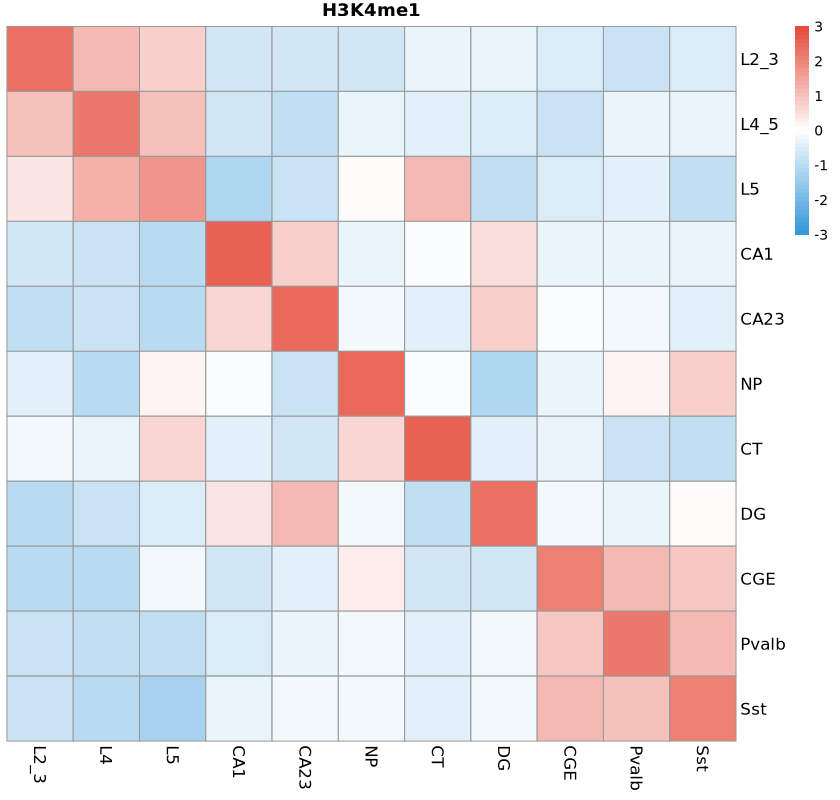

In [61]:
options(repr.plot.width = 8.4, repr.plot.height = 8, repr.plot.res = 100)
pheatmap(
  scaled_heatmap_matrix,
  cluster_rows = FALSE,
  cluster_cols = FALSE,
  color = colorRampPalette(c("#3498db", "white", "#e74c3c"))(50),
  main = "H3K4me1",
  fontsize_row = 12,
  fontsize_col = 12,
  breaks = seq(-3, 3, length.out = 51)
)

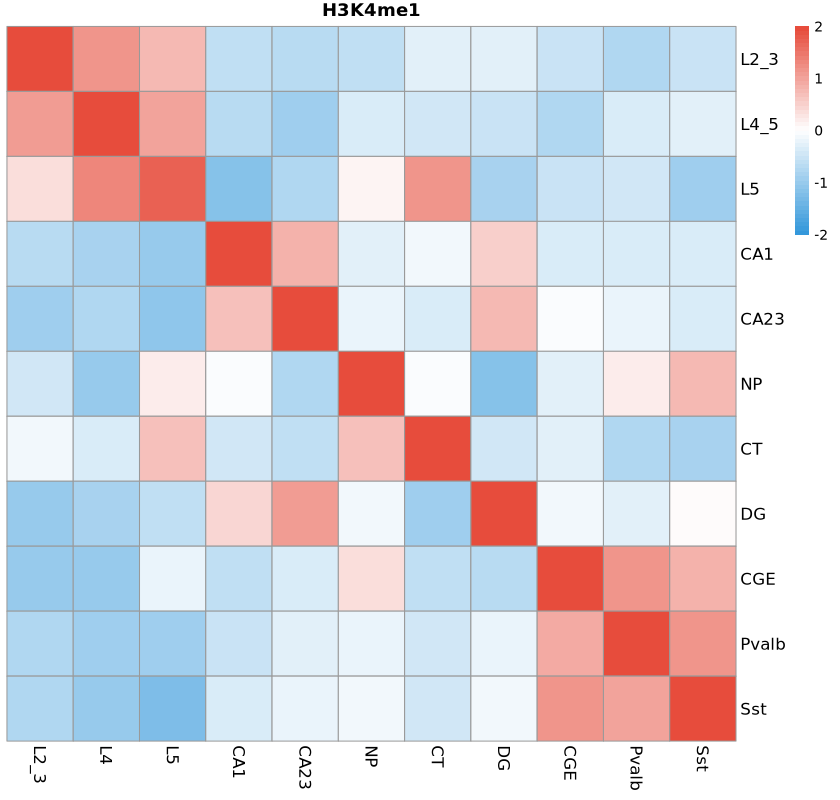

In [62]:
options(repr.plot.width = 8.4, repr.plot.height = 8, repr.plot.res = 100)
pheatmap(
  scaled_heatmap_matrix,
  cluster_rows = FALSE,
  cluster_cols = FALSE,
  color = colorRampPalette(c("#3498db", "white", "#e74c3c"))(50),
  main = "H3K4me1",
  fontsize_row = 12,
  fontsize_col = 12,
  breaks = seq(-2, 2, length.out = 51)
)

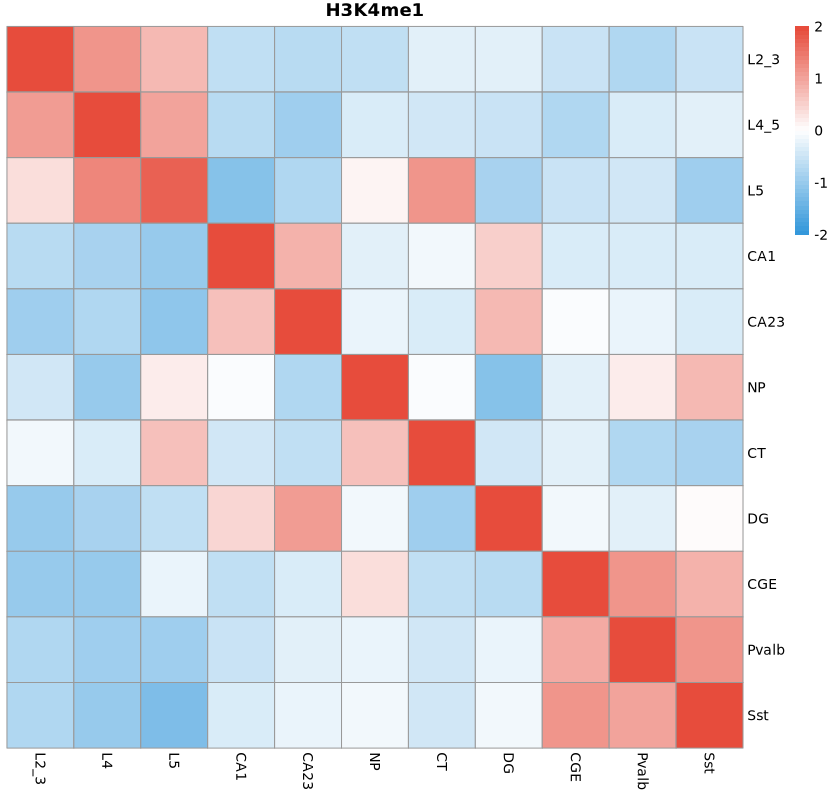

In [63]:
p1 <- pheatmap(
  scaled_heatmap_matrix,
  cluster_rows = FALSE,
  cluster_cols = FALSE,
  color = colorRampPalette(c("#3498db", "white", "#e74c3c"))(50),
  main = "H3K4me1",
  fontsize_row = 10,
  fontsize_col = 10,
  breaks = seq(-2, 2, length.out = 51)
)

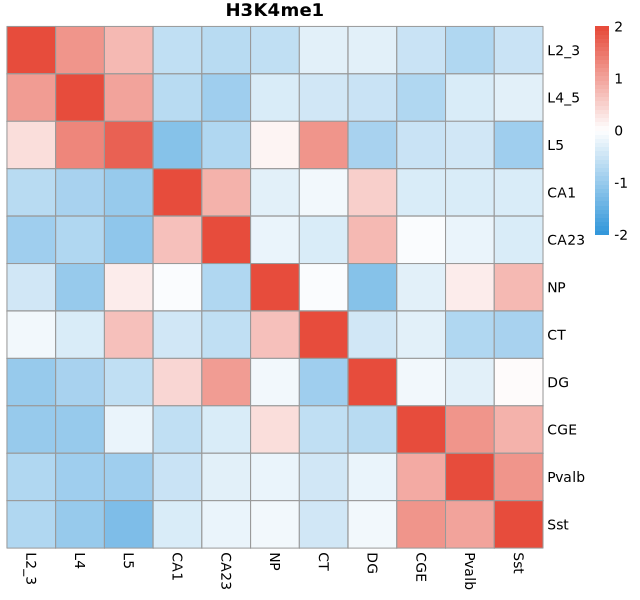

In [64]:
options(repr.plot.width = 6.4, repr.plot.height = 6, repr.plot.res = 100)
p1

In [65]:
pdf("../output/08-H3K4me1_modification_in_hyperDHMR_merge.pdf",width = 6.4,height = 6)
p1
dev.off()

png 
  2

In [ ]:
# Finished!